# AutoML LOOCV (Paired) — FC 전체 + SHAP (4개 모델)

- **Clinical_ONLY**: `vas_t0`, `treatment_group` (2개)
- **Brain_Plus_Clinical**: 위 2개 + FC 전체 (Residualized)
- **제거 변수**: age, sex, **mean_fd** / **타겟**: vas_t1

## 목적

**어떤 ROI가 예측에 기여하는가**를 본다. 단일 모델의 결과는 그 모델의 특성일 수 있으므로,
**4개 모델에서 상위 ROI가 겹치는지**로 강건성을 확인한다.

## 대상 모델과 explainer

| 모델 | Explainer | 계산 |
|---|---|---|
| LinearRegression | `LinearExplainer` | 닫힌 식, 정확 |
| ElasticNet | `LinearExplainer` | 닫힌 식, 정확 |
| RandomForest | `TreeExplainer` | 트리 순회, 정확 |
| XGBoost | `TreeExplainer` | 트리 순회, 정확 |

**SVR은 제외했다.** 커널 모델에는 `KernelExplainer`를 써야 하는데, 모델 내부를 보지 않고
피처 조합을 무작위로 가려가며 `predict`를 반복 호출하는 방식이다. 기본 샘플 수가
`2 × 피처수 + 2048`이라 86개 피처면 한 샘플당 2200회 이상, 여기에 배경 데이터와
LOOCV 44 fold × 2조건이 곱해져 계산 시간이 비현실적이다.
SVR_Linear는 `coef_`가 있으므로 필요하면 계수를 직접 보면 된다.

## 적용 방식 — fold 내부

LOOCV 밖에서 전체 44명으로 모델 하나를 학습해 SHAP을 뽑으면 학습에 쓴 데이터로
그 모델을 설명하는 것이 되어 과적합된 패턴을 그대로 본다. 따라서 각 fold의
`best_estimator_`에서 **그 fold의 test 샘플 1명분 SHAP**을 뽑아 44개를 모은다.

SHAP 값은 원래 **샘플마다** 나온다. 여기서는 (44, n_feat) 배열로 쌓아두고,
피처별 요약이 필요할 때 `mean(|SHAP|)`으로 압축한다. Active/Sham 비교에서는
다시 샘플 단위로 되돌려 쓴다.

## FC_LEVEL — strength 권장

`edge`(3486개)는 학습 샘플 43개당 피처 3486개다. 트리가 사실상 임의의 엣지를
고르게 되므로 SHAP이 노이즈를 설명하게 된다. `strength`(84개)를 주 분석으로 둘 것.

## 해석 시 주의

1. **SHAP은 모델이 학습한 것을 설명할 뿐, 그 학습이 옳았는지는 알려주지 않는다.**
   현재 FC 결과는 Brain 조건이 Clinical을 넘지 못한 상태다. 따라서 상위 ROI를
   "예측에 기여하는 영역"으로 단정할 수 없고, **모델 간·fold 간 일관성이 있을 때만**
   언급 가치가 있다.
2. **LinearRegression은 Brain 조건에서 p > n이라 계수가 발산한다.** morph에서
   RMSE 3.5e10이 나왔던 조건이다. 그 SHAP은 해석하지 말 것. 대조군으로만 둔다.
3. 뇌 피처는 age/sex/mean_fd로 **잔차화된 값**이다. SHAP도 "잔차화된 FC의 기여"다.
4. **SHAP으로 상위 피처를 골라 같은 데이터로 재실행하면 데이터 누수다.**
   이 분석은 보고용이며 피처 선택용이 아니다.
5. 각 환자의 SHAP은 **서로 다른 모델**에서 나왔다(fold마다 GridSearch 결과가 다름).
   일반적인 SHAP 사용법과 다른 부분이므로 논문에 명시할 것.

## morph 노트북과 달라진 점

| | morph | 이 노트북 |
|---|---|---|
| n | 45 | **44** (sub-001은 ses-t0 fmriprep 크래시로 MNI preproc BOLD 없음) |
| 교란변수 | age, sex, **eTIV** | age, sex, **mean_fd** |

## 아틀라스 표기 주의

파일명이 `FreeSurferDKT_`이지만 실제 라벨 세트는 **DK**다
(`bankssts`, `frontalpole`, `temporalpole` 포함 — DKT에서 제거된 라벨. DKT 62개, DK 68개).


In [1]:
import os
os.environ['JOBLIB_TEMP_FOLDER'] = r'C:\SUDMEX\jltmp'
os.makedirs(os.environ['JOBLIB_TEMP_FOLDER'], exist_ok=True)

In [2]:
pip install shap


   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import shap

warnings.filterwarnings('ignore')

In [4]:
# ==========================================================
# 0. 설정 — strength(84) / edge(3486) 선택
# ==========================================================
FC_LEVEL = 'strength'      # 'strength' 또는 'edge'

FC_FILES = {
    'strength': 'fc_strength_68_16.csv',    # ROI별 node strength 84개
    'edge':     'fc_full_84x84_edited.csv', # 상삼각 edge 3486개
}
FC_CSV = FC_FILES[FC_LEVEL]
print('사용 파일:', FC_CSV)


사용 파일: fc_strength_68_16.csv


In [5]:
# ==========================================================
# 1. DATA PREPARATION
# ==========================================================
df = pd.read_csv(FC_CSV, skipinitialspace=True)
df.columns = df.columns.str.strip()

# 앞 7개는 메타(rid, treatment_group, vas_t0, vas_t1, age, sex, mean_fd),
# 8번째 컬럼부터 끝까지가 뇌 피처
X_brain = df.iloc[:, 7:].values
brain_features = df.columns[7:].tolist()

nuisance_covariates = ['age', 'sex', 'mean_fd']    # morph의 eTIV 자리를 mean_fd가 대체
clinical_predictors = ['vas_t0', 'treatment_group']
target = 'vas_t1'

X_nuisance = df[nuisance_covariates].values
X_clinical = df[clinical_predictors].values
y = df[target].values

print(f'n = {len(df)},  brain features = {X_brain.shape[1]}  (p/n = {X_brain.shape[1]/len(df):.1f})')


n = 44,  brain features = 84  (p/n = 1.9)


In [6]:
# ==========================================================
# 2. MODELS & HYPERPARAMETER SETUP
# ==========================================================
# [변경] Baseline 항목 삭제. 모든 모델이 두 데이터셋에 동일하게 적용됨.
models = {
    'LinearRegression': LinearRegression(),
    'ElasticNet': ElasticNet(max_iter=10000, random_state=42),
    'SVR_Linear': SVR(kernel='linear'),
    'SVR_RBF': SVR(kernel='rbf'),
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, objective='reg:squarederror')
}

param_grids = {
    'LinearRegression': {},
    'ElasticNet': {
        'alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0, 100.0],   # 위로 확장
        'l1_ratio': [0.01, 0.05, 0.1, 0.3, 0.5, 0.7, 0.9]    # 아래로 확장
    },
    'SVR_Linear': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],          # 위로
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]                # 위로
    },
    'SVR_RBF': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],          # 위로 (최우선)
        'gamma': ['scale', 0.0001, 0.001, 0.01, 0.1],        # 아래로
        'epsilon': [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    'RandomForest': {
        'n_estimators': [100, 300],
        'max_depth': [None, 2, 3, 5],
        'min_samples_leaf': [1, 3, 5]                        # split보다 leaf가 n작을 때 효과적
    },
    'XGBoost': {
        'n_estimators': [100, 300],
        'max_depth': [2, 3],                                 # n=44면 5는 과함
        'learning_rate': [0.03, 0.1],
        'reg_lambda': [1, 10]                                # 규제 추가
    },
}

DATA_TYPES = ['Clinical_ONLY', 'Brain_Plus_Clinical']

In [7]:
# ==========================================================
# 3. CROSS-VALIDATION PIPELINE (LOOCV)
# ==========================================================
loo = LeaveOneOut()
# [변경] 예측을 (데이터셋, 모델) 조합별로 저장
predictions = {(dt, name): [] for dt in DATA_TYPES for name in models}
best_params_log = {(dt, name): [] for dt in DATA_TYPES for name in models}
y_true = []

# --- SHAP: fold별 test 샘플 1명분 기여도를 모은다 ---
# SVR은 KernelExplainer가 필요해 계산 비용이 비현실적이므로 제외
SHAP_MODELS = {
    'LinearRegression': 'linear',
    'ElasticNet':       'linear',
    'RandomForest':     'tree',
    'XGBoost':          'tree',
}
shap_log = {(dt, name): [] for dt in DATA_TYPES for name in SHAP_MODELS}
shap_feat = {}

print(f"Starting LOOCV: {len(models)} models x {len(DATA_TYPES)} datasets...\n")

for fold_idx, (train_idx, test_idx) in enumerate(loo.split(X_brain)):
    print(f"Processing fold {fold_idx+1}/{len(y)}...", end='\r')

    X_b_train, X_b_test = X_brain[train_idx], X_brain[test_idx]
    X_n_train, X_n_test = X_nuisance[train_idx], X_nuisance[test_idx]
    X_c_train, X_c_test = X_clinical[train_idx], X_clinical[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # --- Nuisance Residualization ---
    nuisance_regressor = LinearRegression()
    nuisance_regressor.fit(X_n_train, X_b_train)
    X_b_train_clean = X_b_train - nuisance_regressor.predict(X_n_train)
    X_b_test_clean = X_b_test - nuisance_regressor.predict(X_n_test)

    # --- Features Stack ---
    X_train_full = np.hstack([X_b_train_clean, X_c_train])
    X_test_full = np.hstack([X_b_test_clean, X_c_test])

    y_true.append(y_test[0])

    # [변경] 두 데이터셋을 딕셔너리로 묶어 동일하게 처리
    raw_sets = {
        'Clinical_ONLY': (X_c_train, X_c_test),
        'Brain_Plus_Clinical': (X_train_full, X_test_full),
    }

    for dt, (X_tr_raw, X_te_raw) in raw_sets.items():
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_tr_raw)
        X_te = scaler.transform(X_te_raw)

        for name, model in models.items():
            inner_cv = GridSearchCV(model, param_grids[name], cv=3,
                                    scoring='neg_mean_squared_error', n_jobs=-1)
            inner_cv.fit(X_tr, y_train)
            pred = inner_cv.best_estimator_.predict(X_te)
            predictions[(dt, name)].append(pred[0])
            best_params_log[(dt, name)].append(str(inner_cv.best_params_))

            # --- SHAP (해당 fold의 best model로 test 1명 설명) ---
            if name in SHAP_MODELS:
                est = inner_cv.best_estimator_
                kind = SHAP_MODELS[name]
                if kind == 'tree':
                    explainer = shap.TreeExplainer(est)
                else:
                    explainer = shap.LinearExplainer(est, X_tr)
                sv = explainer.shap_values(X_te)
                shap_log[(dt, name)].append(np.asarray(sv).reshape(-1))
                if dt not in shap_feat:
                    # X_train_full = hstack([brain, clinical]) 순서와 일치시킨다
                    shap_feat[dt] = (brain_features + clinical_predictors
                                     if dt == 'Brain_Plus_Clinical'
                                     else list(clinical_predictors))

print("\n\nLOOCV Completed.")

Starting LOOCV: 6 models x 2 datasets...

Processing fold 44/44...

LOOCV Completed.


In [8]:
# ==========================================================
# 4. EVALUATION & PAIRED COMPARISON
# ==========================================================
y_true = np.array(y_true)

results = []
for (dt, name), preds in predictions.items():
    y_pred = np.array(preds)
    corr, p_val = pearsonr(y_true, y_pred)
    results.append({
        'Data Type': dt,
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2 Score': r2_score(y_true, y_pred),
        'Pearson (r)': corr,
        'p-value': p_val,
    })

results_df = pd.DataFrame(results)

# --- 기준선: 평균만 예측하는 모델 ---
baseline_rmse = np.sqrt(np.mean([(y_true[i] - np.delete(y_true, i).mean()) ** 2
                                 for i in range(len(y_true))]))
print(f"평균만 예측하는 모델의 LOOCV RMSE = {baseline_rmse:.3f}")
print("  -> 이 값보다 나쁜 모델은 예측력이 없는 것임\n")

# --- Paired 표 (행 = 모델, 열 = 데이터셋) ---
pivot = results_df.pivot(index='Model', columns='Data Type', values='RMSE')
pivot['dRMSE'] = pivot['Clinical_ONLY'] - pivot['Brain_Plus_Clinical']
pivot = pivot.sort_index()   # dRMSE 정렬 안 함 (좋은 것만 골라 읽게 되므로)

n_pos = int((pivot['dRMSE'] > 0).sum())
n_tot = len(pivot)

print("========== PAIRED COMPARISON (RMSE, +면 뇌 추가가 이득) ==========")
display(pivot)

print(f"\n부호 일관성: {n_tot}개 중 {n_pos}개가 +")
if n_pos == n_tot:
    print("  -> 전부 +. 알고리즘 선택과 무관하게 개선.")
elif n_pos == 0:
    print("  -> 전부 -. 뇌 지표가 오히려 해가 됨.")
else:
    print("  -> 부호가 섞임. 효과 없음으로 읽는 것이 타당함.")
    print("  -> 여기서 + 나온 모델만 골라 결론 내지 말 것.")

print("\n========== 전체 지표 ==========")
display(results_df.sort_values(['Model', 'Data Type']))

평균만 예측하는 모델의 LOOCV RMSE = 2.309
  -> 이 값보다 나쁜 모델은 예측력이 없는 것임

========== PAIRED COMPARISON (RMSE, +면 뇌 추가가 이득) ==========


Data Type,Brain_Plus_Clinical,Clinical_ONLY,dRMSE
Model,,,
ElasticNet,2.271435,1.996230,-0.275205
LinearRegression,5.268707,1.997338,-3.271370
RandomForest,2.427648,2.200693,-0.226955
SVR_Linear,2.509863,2.040615,-0.469248
SVR_RBF,2.609394,2.208213,-0.401181
XGBoost,2.330166,2.235297,-0.094869



부호 일관성: 6개 중 0개가 +
  -> 전부 -. 뇌 지표가 오히려 해가 됨.

========== 전체 지표 ==========


,Data Type,Model,RMSE,R2 Score,Pearson (r),p-value
7,Brain_Plus_Clinical,ElasticNet,2.271435,-0.012992,0.138985,0.368249
1,Clinical_ONLY,ElasticNet,1.996230,0.217604,0.477844,0.001037
6,Brain_Plus_Clinical,LinearRegression,5.268707,-4.450214,-0.057177,0.712385
0,Clinical_ONLY,LinearRegression,1.997338,0.216736,0.478364,0.001022
10,Brain_Plus_Clinical,RandomForest,2.427648,-0.157116,0.071402,0.645101
4,Clinical_ONLY,RandomForest,2.200693,0.049123,0.327847,0.029816
8,Brain_Plus_Clinical,SVR_Linear,2.509863,-0.236817,-0.170015,0.269878
2,Clinical_ONLY,SVR_Linear,2.040615,0.182425,0.449354,0.002214
9,Brain_Plus_Clinical,SVR_RBF,2.609394,-0.336856,-0.290321,0.055911
3,Clinical_ONLY,SVR_RBF,2.208213,0.042613,0.347018,0.021009


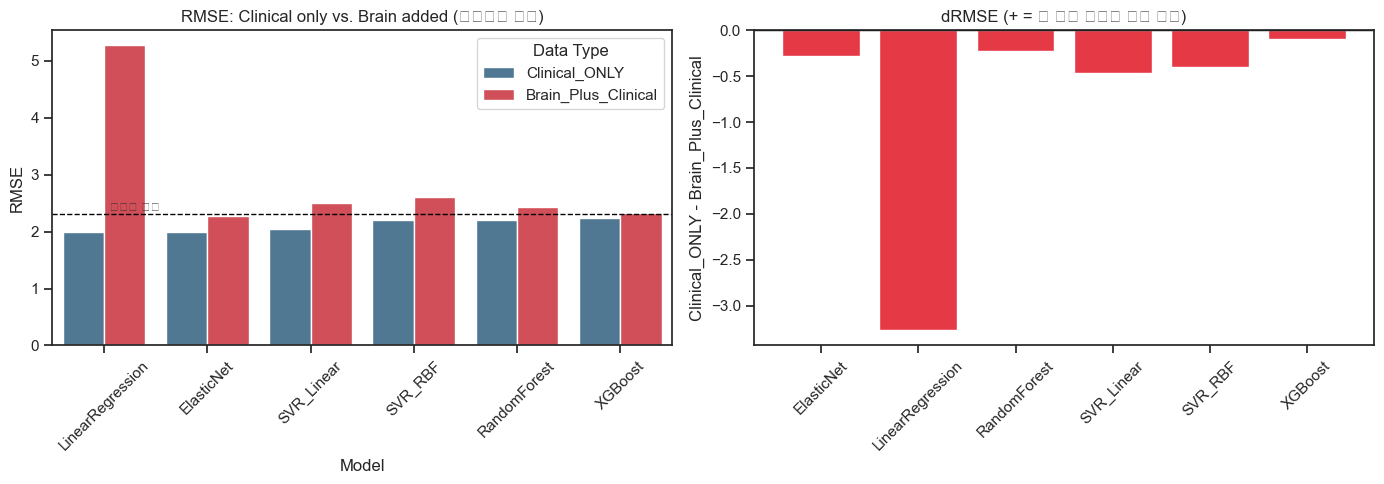

In [9]:
# ==========================================================
# 5. VISUALIZATION (Paired)
# ==========================================================
sns.set_theme(style="ticks")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 모델별 RMSE를 데이터셋으로 나눠 나란히
sns.barplot(data=results_df, x='Model', y='RMSE', hue='Data Type',
            palette=['#457B9D', '#E63946'], ax=axes[0])
axes[0].axhline(baseline_rmse, color='black', linestyle='--', linewidth=1)
axes[0].text(0.02, baseline_rmse, ' 평균만 예측', va='bottom', fontsize=9)
axes[0].set_title('RMSE: Clinical only vs. Brain added (낮을수록 좋음)')
axes[0].tick_params(axis='x', rotation=45)

# 오른쪽: dRMSE
colors = ['#2A9D8F' if v > 0 else '#E63946' for v in pivot['dRMSE']]
axes[1].bar(pivot.index, pivot['dRMSE'], color=colors)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('dRMSE (+ = 뇌 지표 추가로 오차 감소)')
axes[1].set_ylabel('Clinical_ONLY - Brain_Plus_Clinical')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [10]:
# ==========================================================
# 6. 하이퍼파라미터 안정성 (선택 사항)
# ==========================================================
for (dt, name), plist in best_params_log.items():
    vc = pd.Series(plist).value_counts()
    share = vc.iloc[0] / vc.sum()
    flag = '' if share >= 0.5 else '   <-- 불안정'
    print(f"[{name} / {dt}] 고유 조합 {len(vc)}개, 최빈 {share:.0%}{flag}")

[LinearRegression / Clinical_ONLY] 고유 조합 1개, 최빈 100%
[ElasticNet / Clinical_ONLY] 고유 조합 1개, 최빈 100%
[SVR_Linear / Clinical_ONLY] 고유 조합 12개, 최빈 43%   <-- 불안정
[SVR_RBF / Clinical_ONLY] 고유 조합 7개, 최빈 84%
[RandomForest / Clinical_ONLY] 고유 조합 5개, 최빈 61%
[XGBoost / Clinical_ONLY] 고유 조합 4개, 최빈 86%
[LinearRegression / Brain_Plus_Clinical] 고유 조합 1개, 최빈 100%
[ElasticNet / Brain_Plus_Clinical] 고유 조합 3개, 최빈 73%
[SVR_Linear / Brain_Plus_Clinical] 고유 조합 6개, 최빈 80%
[SVR_RBF / Brain_Plus_Clinical] 고유 조합 9개, 최빈 39%   <-- 불안정
[RandomForest / Brain_Plus_Clinical] 고유 조합 9개, 최빈 36%   <-- 불안정
[XGBoost / Brain_Plus_Clinical] 고유 조합 7개, 최빈 27%   <-- 불안정


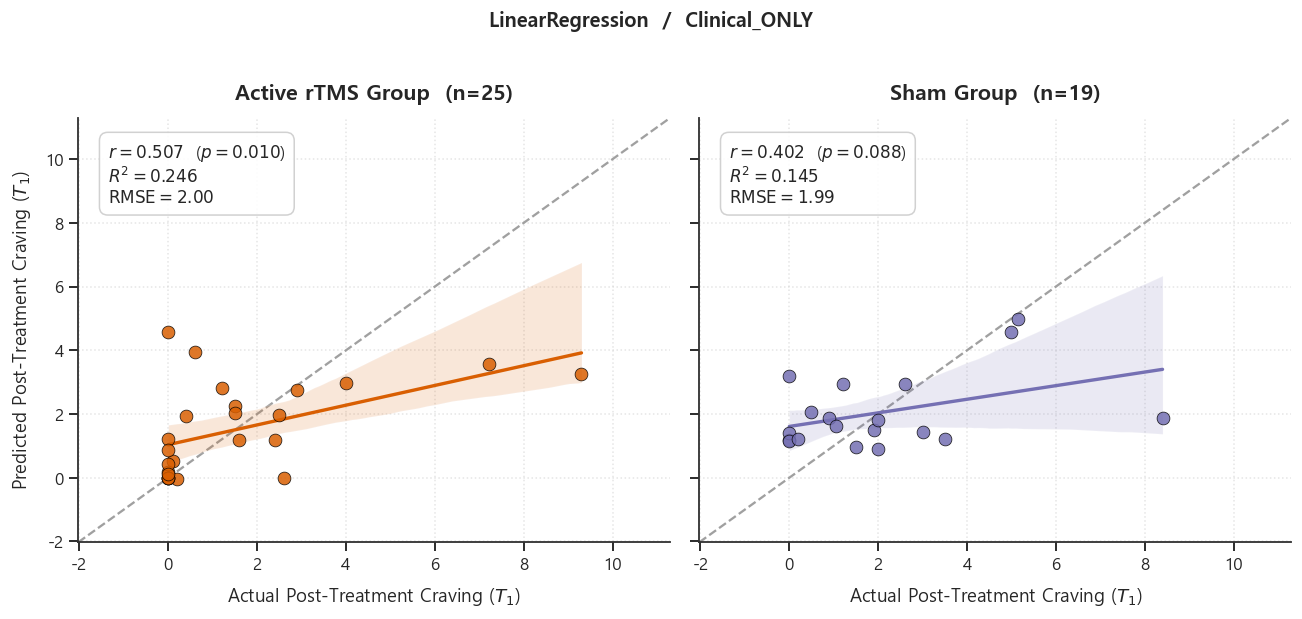

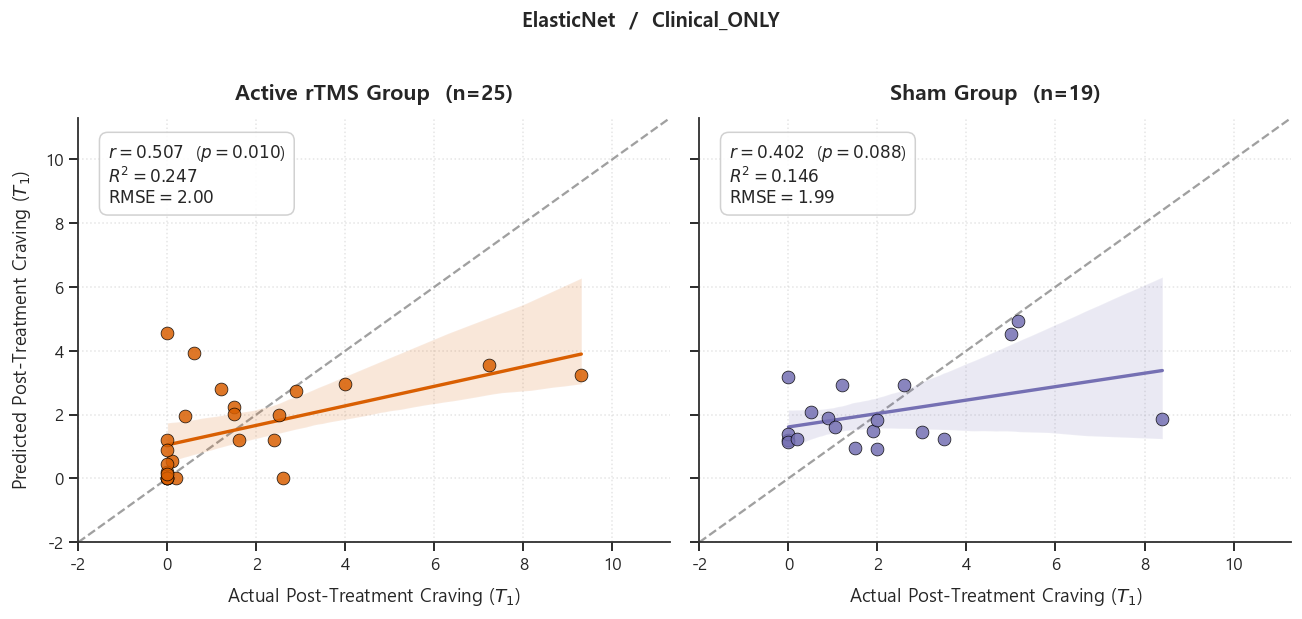

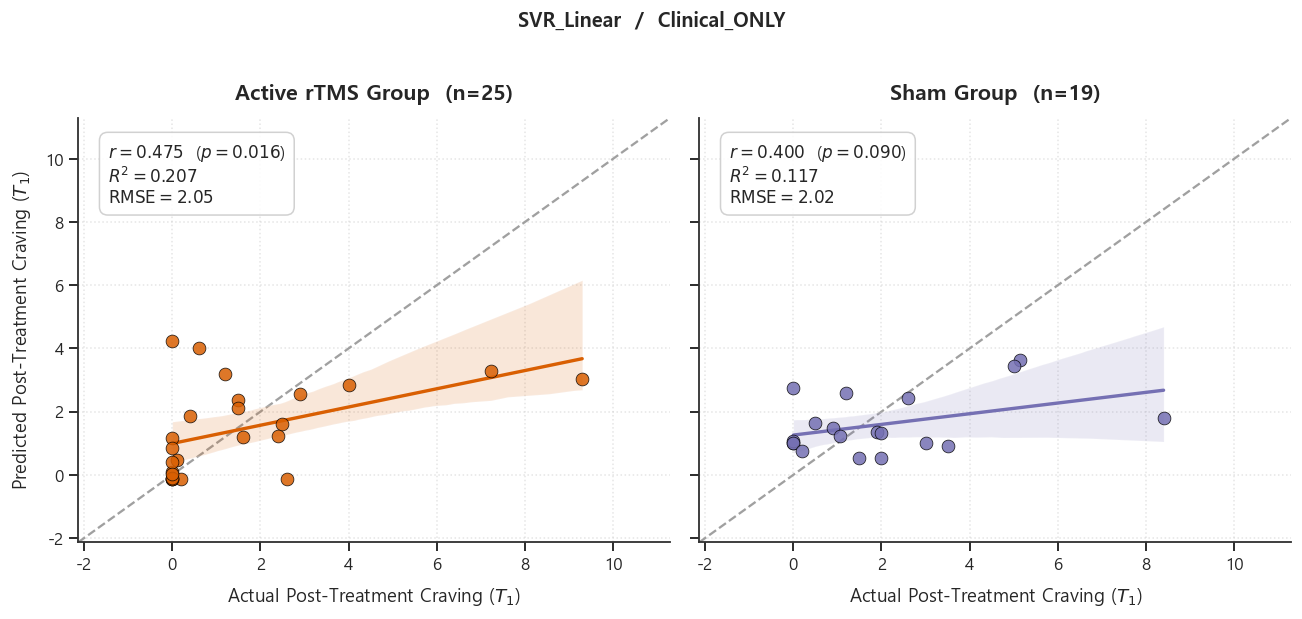

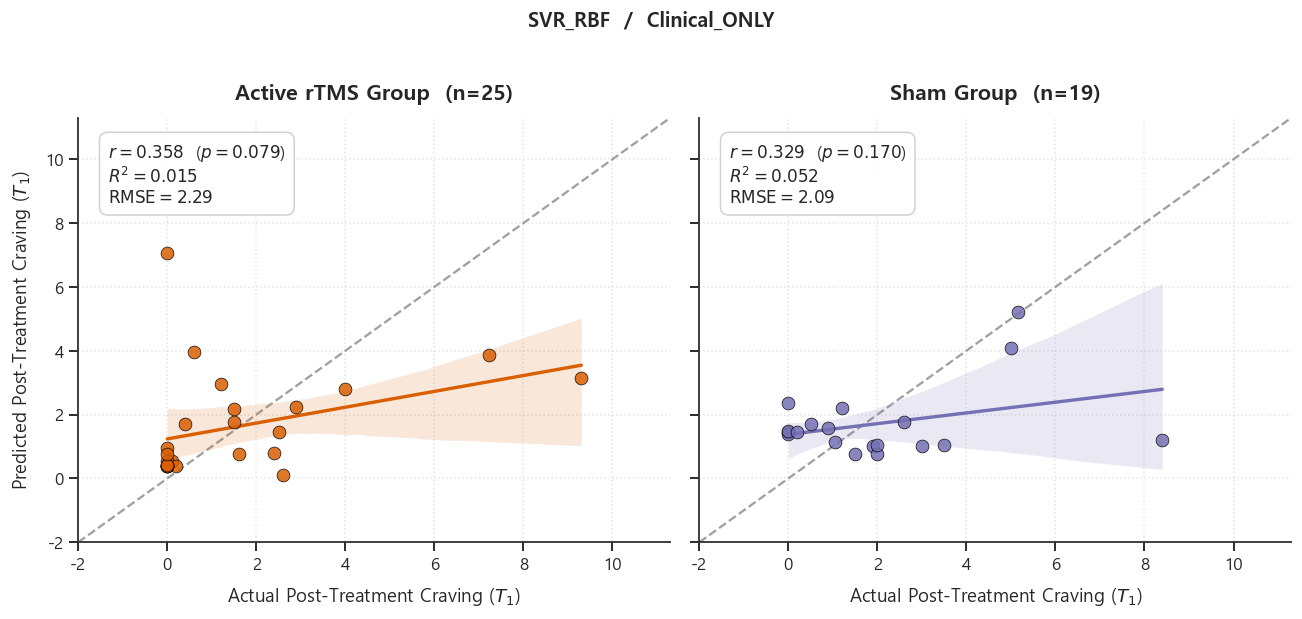

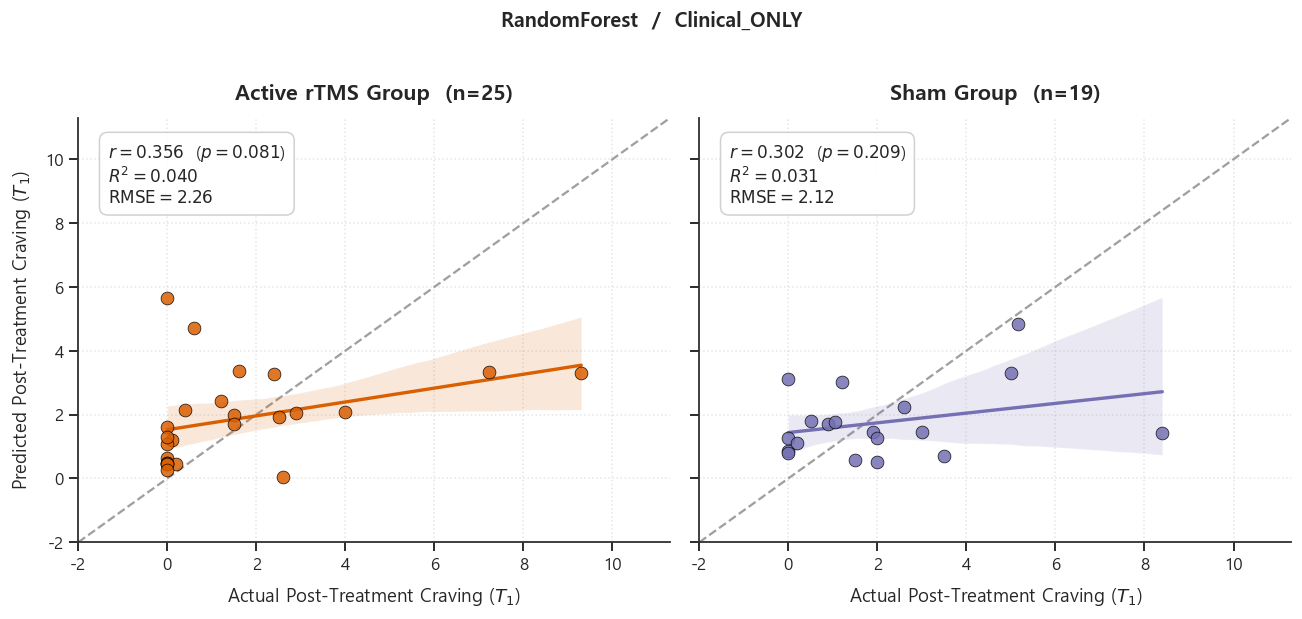

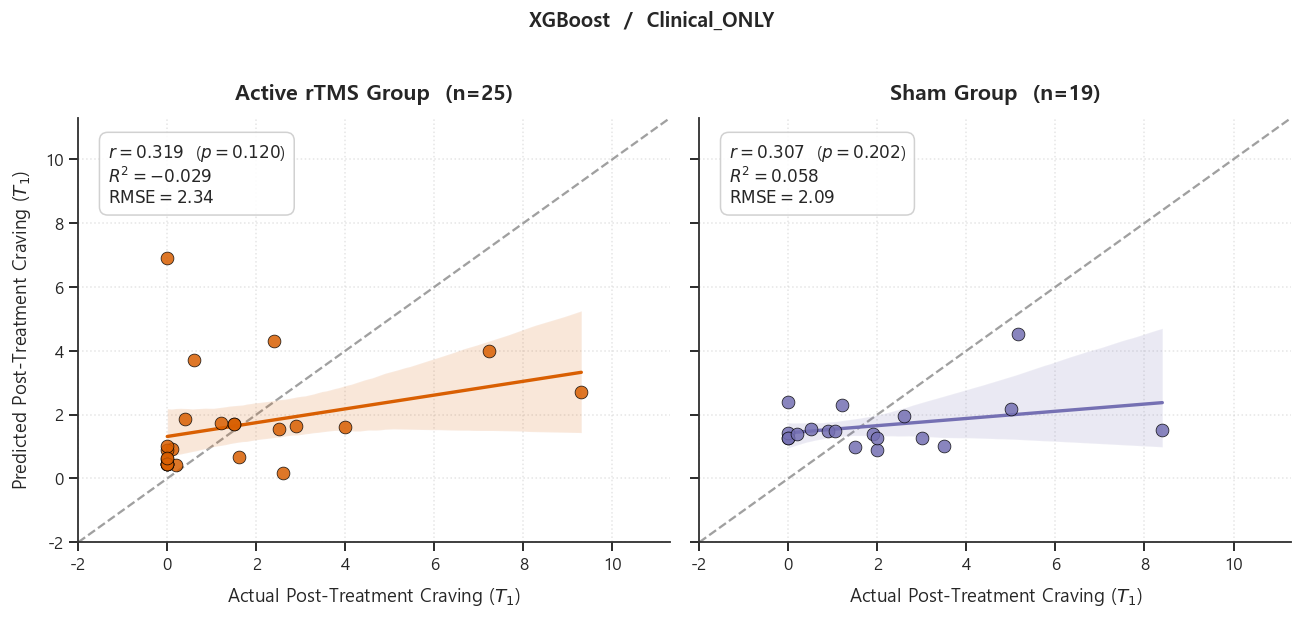

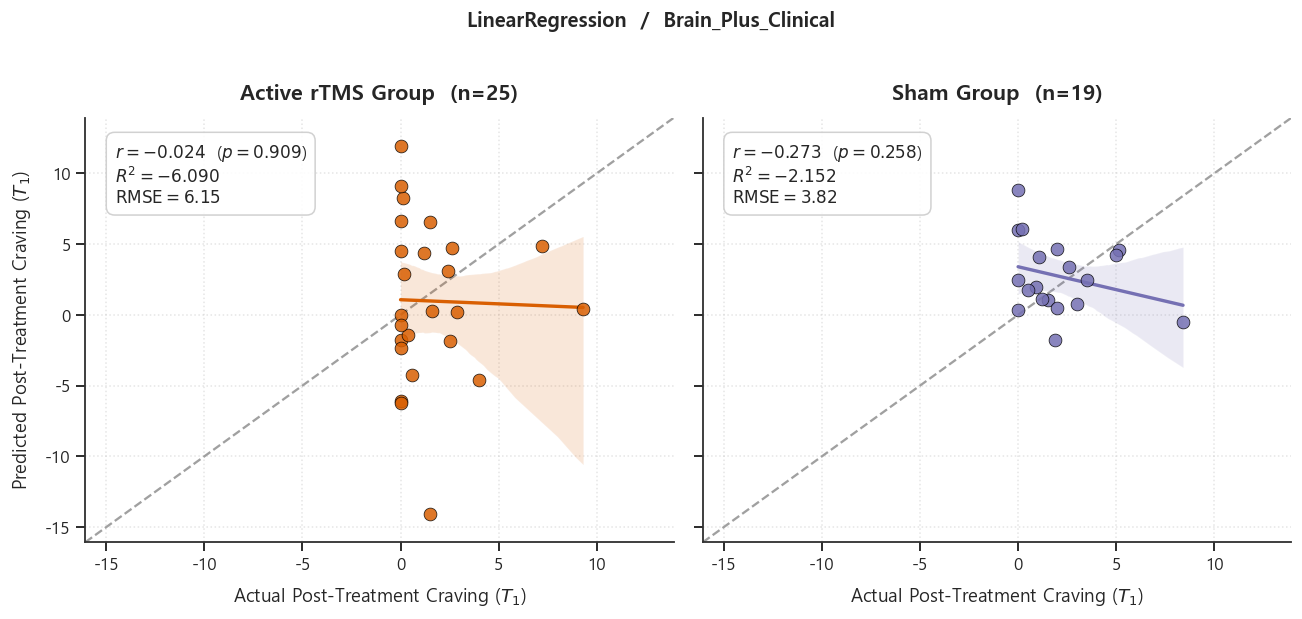

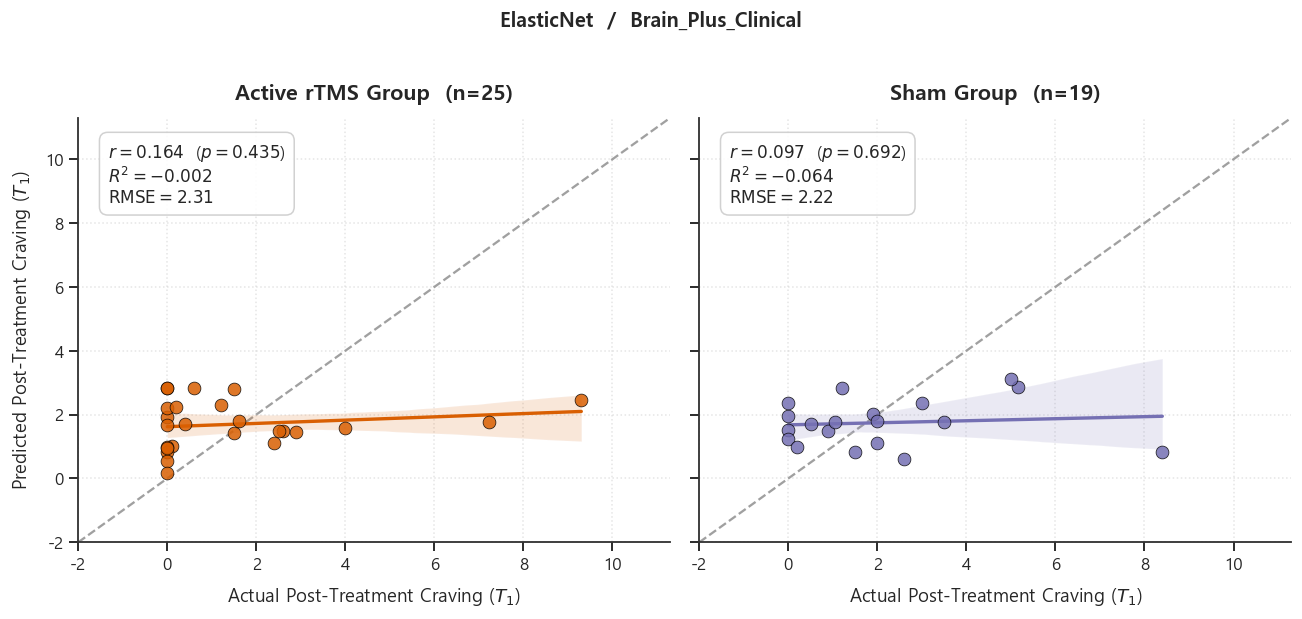

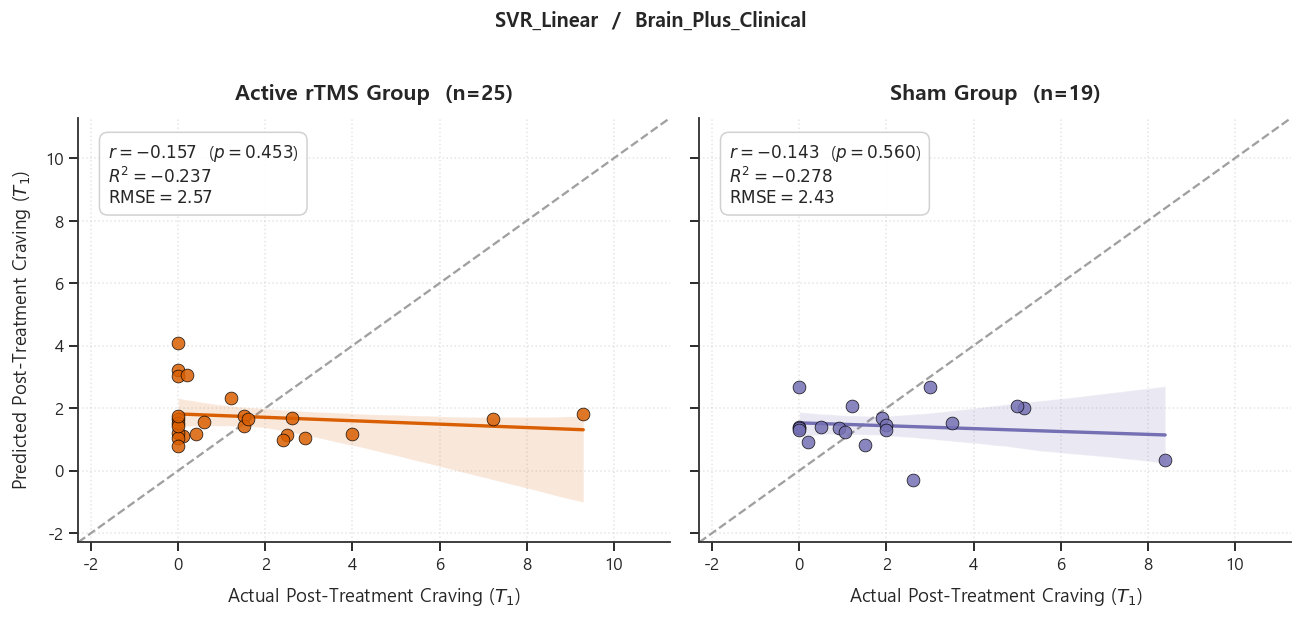

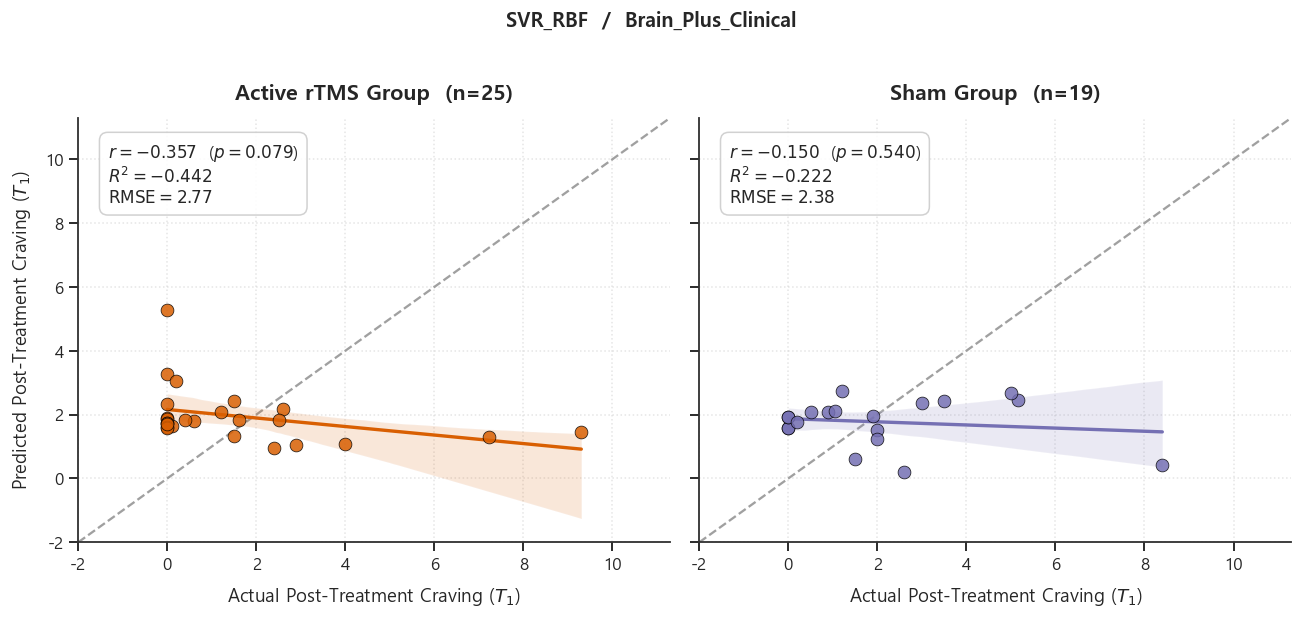

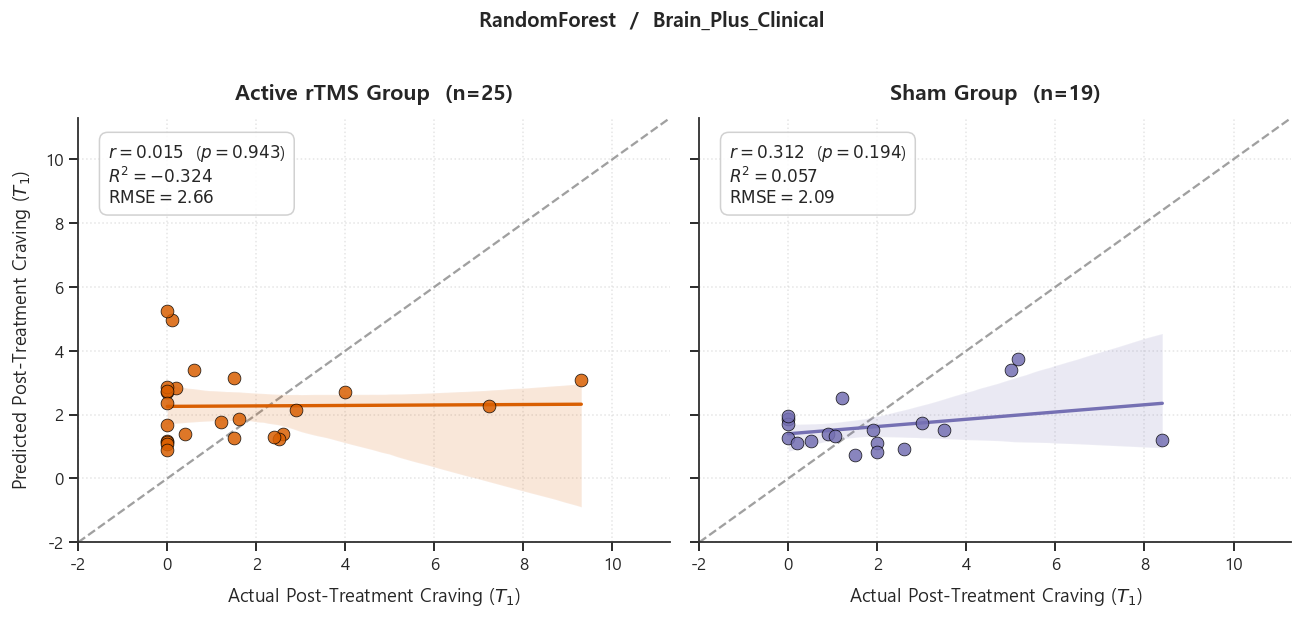

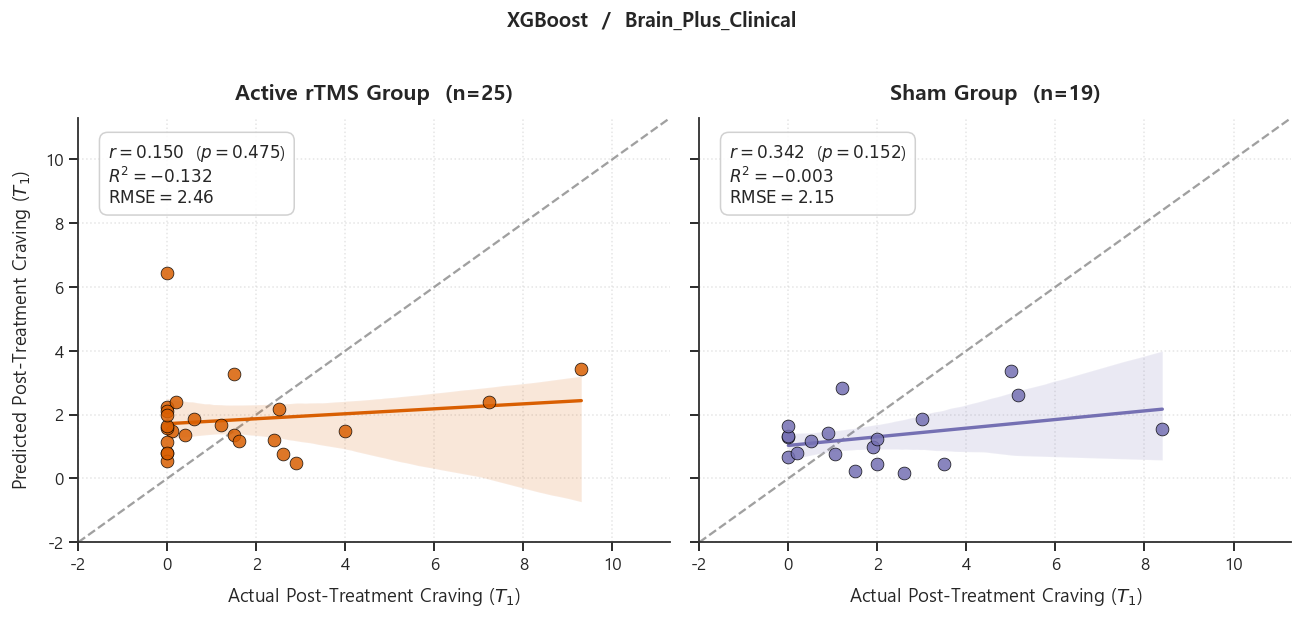

In [11]:
# ==========================================================
# 9. Active vs Sham — 12세트 전부
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

sns.set_theme(style="ticks")
plt.rcParams['font.sans-serif'] = 'Malgun Gothic'   # Helvetica는 Windows에 없음
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.2

palette = {'Active rTMS': '#D95F02', 'Sham': '#7570B3'}
groups = ['Active rTMS', 'Sham']

for (dt, name), preds in predictions.items():
    y_pred = np.array(preds)

    plot_df = pd.DataFrame({
        'True_Craving': y,
        'Pred_Craving': y_pred,
        'Group': np.where(df['treatment_group'].values == 2, 'Active rTMS', 'Sham')
    })

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True, dpi=110)

    min_val = min(plot_df['True_Craving'].min(), plot_df['Pred_Craving'].min()) - 2
    max_val = max(plot_df['True_Craving'].max(), plot_df['Pred_Craving'].max()) + 2

    for i, grp in enumerate(groups):
        ax = axes[i]
        sub_df = plot_df[plot_df['Group'] == grp]
        color = palette[grp]

        r, pval = pearsonr(sub_df['True_Craving'], sub_df['Pred_Craving'])
        r2 = r2_score(sub_df['True_Craving'], sub_df['Pred_Craving'])
        rmse = np.sqrt(np.mean((sub_df['True_Craving'] - sub_df['Pred_Craving'])**2))

        ax.plot([min_val, max_val], [min_val, max_val],
                color='#A0A0A0', linestyle='--', linewidth=1.5, zorder=1)

        sns.scatterplot(
            data=sub_df, x='True_Craving', y='Pred_Craving',
            color=color, s=70, alpha=0.85, edgecolor='black',
            linewidth=0.5, ax=ax, zorder=3
        )

        sns.regplot(
            data=sub_df, x='True_Craving', y='Pred_Craving',
            ax=ax, scatter=False, color=color, line_kws={'linewidth': 2.2}, ci=95
        )

        ax.set_title(f'{grp} Group  (n={len(sub_df)})',
                     fontsize=14, fontweight='bold', pad=12)
        ax.set_xlabel('Actual Post-Treatment Craving ($T_1$)', fontsize=12, labelpad=8)
        if i == 0:
            ax.set_ylabel('Predicted Post-Treatment Craving ($T_1$)', fontsize=12, labelpad=8)

        stats_text = (f"$r = {r:.3f}$  ($p = {pval:.3f}$)\n"
                      f"$R^2 = {r2:.3f}$\n"
                      f"$\\mathrm{{RMSE}} = {rmse:.2f}$")
        ax.text(
            0.05, 0.80, stats_text, transform=ax.transAxes, fontsize=11,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      alpha=0.9, edgecolor='#CCCCCC')
        )

        ax.set_xlim(min_val, max_val)
        ax.set_ylim(min_val, max_val)
        ax.grid(True, linestyle=':', alpha=0.5)

    fig.suptitle(f'{name}  /  {dt}', fontsize=13, fontweight='bold', y=1.02)
    sns.despine()
    plt.tight_layout()
    plt.show()

---
# SHAP 분석

`share_%`는 그 피처가 전체 기여에서 차지하는 비중이다.

`mean_shap`(부호 포함)과 `mean_abs_shap`를 함께 보면 상쇄 여부를 알 수 있다 —
`mean_abs`는 큰데 `mean`이 0에 가까우면 샘플마다 기여 방향이 반대라는 뜻이다.

In [12]:
# ==========================================================
# 7. SHAP - 모델별 피처 기여도
# ==========================================================
shap_summary = {}

for (dt, name), logs in shap_log.items():
    S = np.array(logs)                      # (n_fold, n_feat)
    feats = shap_feat[dt]
    assert S.shape[1] == len(feats), f'{dt}/{name} 피처 수 불일치: {S.shape[1]} vs {len(feats)}'

    imp = pd.DataFrame({
        'feature': feats,
        'mean_abs_shap': np.abs(S).mean(axis=0),
        'mean_shap': S.mean(axis=0),
    })
    tot = imp['mean_abs_shap'].sum()
    imp['share_%'] = imp['mean_abs_shap'] / tot * 100 if tot > 0 else 0.0
    imp = imp.sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
    shap_summary[(dt, name)] = imp

DT_MAIN = 'Brain_Plus_Clinical'

for name in SHAP_MODELS:
    imp = shap_summary[(DT_MAIN, name)]
    clin = imp[imp['feature'].isin(clinical_predictors)]['share_%'].sum()
    print(f"\n===== {name} / {DT_MAIN} =====")
    print(imp.head(10).round(4).to_string(index=False))
    print(f"  임상 2개 {clin:.1f}%  |  뇌 피처 전체 {100-clin:.1f}%")


===== LinearRegression / Brain_Plus_Clinical =====
                  feature  mean_abs_shap  mean_shap  share_%
             lh_cuneus_fc         1.7373     0.0405   4.5145
          treatment_group         1.3830     0.0183   3.5938
           rh_Pallidum_fc         1.3489    -0.0734   3.5053
            lh_lingual_fc         1.1040    -0.0199   2.8687
rh_caudalmiddlefrontal_fc         1.0762    -0.0198   2.7966
            rh_Caudate_fc         1.0558    -0.0399   2.7437
      rh_parsorbitalis_fc         0.9552     0.0037   2.4821
lh_medialorbitofrontal_fc         0.8845    -0.0253   2.2986
           lh_Pallidum_fc         0.8645     0.0201   2.2465
       rh_temporalpole_fc         0.8398    -0.0085   2.1823
  임상 2개 5.3%  |  뇌 피처 전체 94.7%

===== ElasticNet / Brain_Plus_Clinical =====
               feature  mean_abs_shap  mean_shap  share_%
                vas_t0         0.4250    -0.0213  22.9399
        rh_Pallidum_fc         0.1902    -0.0120  10.2691
          lh_cuneus_fc    

In [13]:
# ==========================================================
# 8. 모델 4개 x 상위 10개 ROI 나란히 비교
# ==========================================================
TOP_N = 10

# --- 표 1: 순위별 피처 이름 ---
side = pd.DataFrame({
    name: shap_summary[(DT_MAIN, name)]['feature'].head(TOP_N).values
    for name in SHAP_MODELS
}, index=[f'{i+1}위' for i in range(TOP_N)])

print(f"===== {DT_MAIN} | 모델별 상위 {TOP_N}개 =====")
print(side.to_string())

# --- 표 2: 몇 개 모델에서 상위 N위에 들었나 ---
from collections import Counter
cnt = Counter()
for name in SHAP_MODELS:
    cnt.update(shap_summary[(DT_MAIN, name)]['feature'].head(TOP_N).tolist())

overlap = (pd.DataFrame(cnt.items(), columns=['feature', 'n_models'])
             .sort_values('n_models', ascending=False))
for name in SHAP_MODELS:
    r = shap_summary[(DT_MAIN, name)].set_index('feature')['share_%']
    overlap[f'{name[:8]}_%'] = overlap['feature'].map(r).round(2)

print(f"\n===== 모델 간 교집합 (상위 {TOP_N} 기준, {len(SHAP_MODELS)}개 중) =====")
print(overlap.to_string(index=False))

n_all = (overlap['n_models'] == len(SHAP_MODELS)).sum()
print(f"\n  4개 모델 전부에서 상위 {TOP_N}: {n_all}개")
print("  -> 0개에 가까우면 모델마다 다른 ROI를 골랐다는 뜻 = 노이즈일 가능성")

===== Brain_Plus_Clinical | 모델별 상위 10개 =====
              LinearRegression              ElasticNet                RandomForest                        XGBoost
1위                lh_cuneus_fc                  vas_t0                      vas_t0                         vas_t0
2위             treatment_group          rh_Pallidum_fc              rh_Pallidum_fc                 rh_Pallidum_fc
3위              rh_Pallidum_fc            lh_cuneus_fc                lh_cuneus_fc     rh_rostralmiddlefrontal_fc
4위               lh_lingual_fc        rh_entorhinal_fc      rh_superiortemporal_fc                 lh_bankssts_fc
5위   rh_caudalmiddlefrontal_fc         treatment_group  rh_rostralmiddlefrontal_fc      rh_caudalmiddlefrontal_fc
6위               rh_Caudate_fc        lh_entorhinal_fc      lh_superiortemporal_fc                rh_Accumbens_fc
7위         rh_parsorbitalis_fc   lh_parsopercularis_fc              lh_Amygdala_fc            rh_parsorbitalis_fc
8위   lh_medialorbitofrontal_fc  lh_superior

---
## fold 안정성

모델 간 일치와 별개로, **같은 모델 안에서 fold를 바꿔도 같은 ROI가 나오는지** 본다.
44 fold 중 몇 번이나 상위 5위에 들었는지 센다. 40회 이상이면 우연으로 보기 어렵고,
5~10회 수준이면 fold마다 다른 ROI가 뽑히는 것이므로 노이즈다.

In [14]:
# ==========================================================
# 9. fold 안정성 - 상위 5위 진입 횟수
# ==========================================================
TOP_K = 5

for name in SHAP_MODELS:
    S = np.abs(np.array(shap_log[(DT_MAIN, name)]))     # (n_fold, n_feat)
    feats = np.array(shap_feat[DT_MAIN])
    n_fold = S.shape[0]

    hits = Counter()
    for row in S:
        hits.update(feats[np.argsort(-row)[:TOP_K]].tolist())

    st = (pd.DataFrame(hits.items(), columns=['feature', 'top5_count'])
            .sort_values('top5_count', ascending=False).head(10))
    st['rate_%'] = (st['top5_count'] / n_fold * 100).round(1)

    print(f"\n===== {name} / {DT_MAIN}  (n_fold={n_fold}) =====")
    print(st.to_string(index=False))


===== LinearRegression / Brain_Plus_Clinical  (n_fold=44) =====
                  feature  top5_count  rate_%
          treatment_group          24    54.5
           rh_Pallidum_fc          23    52.3
             lh_cuneus_fc          23    52.3
            lh_lingual_fc          15    34.1
            rh_Caudate_fc          14    31.8
lh_medialorbitofrontal_fc          13    29.5
      rh_parsorbitalis_fc          12    27.3
         lh_entorhinal_fc          10    22.7
rh_caudalmiddlefrontal_fc           9    20.5
       rh_temporalpole_fc           6    13.6

===== ElasticNet / Brain_Plus_Clinical  (n_fold=44) =====
               feature  top5_count  rate_%
                vas_t0          40    90.9
        rh_Pallidum_fc          29    65.9
          lh_cuneus_fc          27    61.4
      rh_entorhinal_fc          24    54.5
       treatment_group          22    50.0
      lh_entorhinal_fc          12    27.3
 lh_parsopercularis_fc          10    22.7
 rh_parsopercularis_fc    